<a href="https://colab.research.google.com/github/abhishekCS0024/LangGraph/blob/main/Persistance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langchain langchain_core langchain_groq langchain_community langchain langgraph

In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
load_dotenv()

False

In [9]:
from google.colab import userdata
llm=ChatGroq(
    temperature=0,
    groq_api_key=userdata.get('Groq'),
    model_name="qwen/qwen3-32b",
    verbose=True
)

In [10]:
class ChatState(TypedDict):
  messages:Annotated[list[BaseMessage],add_messages]

In [11]:
def chat_node(state:ChatState):
  mess=llm.invoke(state['messages'])
  state['messages'].append(mess)

In [12]:
graph=StateGraph(ChatState)

In [14]:
graph.add_node('ChatNode',chat_node)

In [15]:
graph.add_edge(START,'ChatNode')
graph.add_edge('ChatNode',END)

In [ ]:
# workflow=graph.compile()

In [27]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

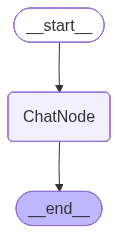

In [28]:
workflow

In [25]:
# workflow.invoke({'messages':[HumanMessage(content='What is the capital of india')]})

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='365eb417-6972-4031-bb01-9d17a17558fb'),
  AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New Delhi is the capital, but I should make sure I\'m not confusing it with Delhi. Wait, Delhi is a city, and New Delhi is a part of it, right? Let me think.\n\nIndia is a country in South Asia. The capital city is where the government is located. Before independence, the capital was Calcutta, but then it was moved to Delhi. After independence in 1947, New Delhi became the capital. So, New Delhi is the correct answer. But I should explain the difference between Delhi and New Delhi to avoid confusion. Delhi is a larger area, and New Delhi is the specific part that serves as the capital. Also, Delhi is a union territory, and New Delhi is the capital city within that ter

In [29]:
config1={'configurable':{"thread_id":"1"}}
workflow.invoke({'messages':[HumanMessage(content='What is the capital of india')]},config=config1)

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='0d695536-e15a-4cd2-bf47-029a5f6c833b'),
  AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New Delhi is the capital, but I should make sure I\'m not confusing it with Delhi. Wait, Delhi is a city, and New Delhi is a part of it, right? Let me think.\n\nIndia is a country in South Asia. The capital city is where the government is located. Before independence, the capital was Calcutta, but then it was moved to Delhi. After independence in 1947, New Delhi became the capital. So, New Delhi is the correct answer. But I should explain the difference between Delhi and New Delhi to avoid confusion. Delhi is a larger area, and New Delhi is the specific part that serves as the capital. Also, Delhi is a union territory, and New Delhi is the capital city within that ter

In [30]:
workflow.get_state(config1)

StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='0d695536-e15a-4cd2-bf47-029a5f6c833b')]}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0db34b-d4d7-692e-8001-2137bdb6b83b'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-12-17T10:40:00.923851+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0db34b-ca49-644c-8000-59cfca3f6f32'}}, tasks=(), interrupts=())

In [31]:
workflow.invoke({'messages':[HumanMessage(content='What is the capital of Russia')]},config=config1)

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='0d695536-e15a-4cd2-bf47-029a5f6c833b'),
  HumanMessage(content='What is the capital of Russia', additional_kwargs={}, response_metadata={}, id='41916c6a-9359-434e-8b2a-0104bddcdaed'),
  AIMessage(content="<think>\nOkay, the user asked for the capital of Russia. Let me recall. I know that Russia is a large country, and I think the capital is Moscow. But wait, I should double-check to be sure. Sometimes countries have cities that are major cities but not capitals. For example, St. Petersburg is a big city in Russia, but I don't think it's the capital. Let me confirm.\n\nI remember that Moscow is the capital. It's the political, economic, and cultural center. It's also the largest city in Russia. The government institutions, like the Kremlin, are there. Yeah, that's right. So the answer should be Moscow. I should also mention that it's the largest city and maybe note the popu

In [32]:
workflow.get_state(config1)


StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='0d695536-e15a-4cd2-bf47-029a5f6c833b'), HumanMessage(content='What is the capital of Russia', additional_kwargs={}, response_metadata={}, id='41916c6a-9359-434e-8b2a-0104bddcdaed')]}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0db34e-f032-6b44-8004-0d1e1b833cf2'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2025-12-17T10:41:24.322971+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0db34e-e914-658e-8003-9d96812b3593'}}, tasks=(), interrupts=())

In [35]:
config2={'configurable':{"thread_id":"2"}}
workflow.invoke({'messages':[HumanMessage(content='What is the capital of bihar')]},config=config2)

{'messages': [HumanMessage(content='What is the capital of bihar', additional_kwargs={}, response_metadata={}, id='5545e19d-4eba-4ed0-97db-6e70604eea17'),
  HumanMessage(content='What is the capital of bihar', additional_kwargs={}, response_metadata={}, id='358cf338-a8d6-45f8-82da-53dc0d942888'),
  AIMessage(content="<think>\nOkay, the user is asking for the capital of Bihar again. Let me check my previous response. I mentioned Patna as the capital. I should confirm that it's correct. Bihar is a state in India, and Patna is indeed its capital. Maybe the user wants more details this time. Should I add some information about Patna? Like its history or significance? The user might be a student or someone preparing for a test. Including a bit about Patna's role as a cultural and historical hub could be helpful. Also, maybe mention that it's located on the Ganges River. Let me make sure there's no confusion with other cities. No, Patna is definitely the capital. I should keep the answer con

In [36]:
workflow.get_state(config2)


StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of bihar', additional_kwargs={}, response_metadata={}, id='5545e19d-4eba-4ed0-97db-6e70604eea17'), HumanMessage(content='What is the capital of bihar', additional_kwargs={}, response_metadata={}, id='358cf338-a8d6-45f8-82da-53dc0d942888')]}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0db355-b8a2-65b0-8004-92f040887728'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2025-12-17T10:44:26.401490+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0db355-b26d-69fd-8003-bf8660adf61f'}}, tasks=(), interrupts=())